# MAJOR PROJECT: SEASONAL AGRICULTURE PERFORMANCE ANALYSIS
# VOIS AICTE Batch 1, 2026-2027


# PROJECT OVERVIEW :
## This notebook analyzes seasonal variations in agricultural performance using environmental, resource-usage and economic indicators recorded across farms.
## Each section below corresponds to one of the key analytical questions defined in the project brief.

## *1. IMPORTING REQUIRED LIBRARIES*

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Global plotting style
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.titleweight"] = "bold"
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 150)

SEASON_ORDER = ["Kharif", "Rabi", "Zaid"]
PALETTE = "viridis"

# *2. LOADING THE DATASET*

In [ ]:
df = pd.read_csv("seasonal_agriculture_performance_dataset.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (4000, 28)


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,7.14,32.8,75.8,61.3,91.0,Drip,242.7,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,5.20,32.0,82.1,35.4,121.8,Flood,271.4,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,5.82,8.1,118.5,51.5,117.9,Drip,162.6,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,5.98,23.7,138.6,55.6,115.5,Rainfed,182.2,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,6.90,29.3,124.1,69.0,121.4,Flood,244.9,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


# *3. INITIAL DATA EXPLORATION*

In [ ]:
print("=" * 80)
print("DATASET INFO")
print("=" * 80)
df.info()

print("\n" + "=" * 80)
print("STATISTICAL SUMMARY (NUMERICAL COLUMNS)")
print("=" * 80)
display(df.describe().T)

print("\n" + "=" * 80)
print("MISSING VALUES PER COLUMN")
print("=" * 80)
missing = df.isnull().sum()
print(missing[missing > 0])

print("\n" + "=" * 80)
print("DUPLICATE ROWS")
print("=" * 80)
print("Duplicate rows found:", df.duplicated().sum())

print("\n" + "=" * 80)
print("UNIQUE VALUES IN KEY CATEGORICAL COLUMNS")
print("=" * 80)
for col in ["Season", "State", "Crop", "Irrigation_Method"]:
    print(f"\n{col} ({df[col].nunique()} unique values):")
    print(df[col].value_counts())


DATASET INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000

,count,mean,std,min,25%,50%,75%,max
Farm_Area_Hectares,4000.0,7.888265,4.223764,0.500,4.260,7.8950,11.65000,15.00
Rainfall_mm,3952.0,601.152657,288.925025,80.000,370.200,582.0000,834.95000,1395.20
Avg_Temperature_C,4000.0,26.818900,3.818180,16.200,23.900,26.9000,29.60000,39.70
Humidity_pct,4000.0,63.210500,11.960834,25.000,54.775,63.0000,71.90000,95.00
Sunlight_Hours_Day,4000.0,7.323050,1.121186,3.500,6.600,7.3000,8.10000,11.00
Soil_pH,4000.0,6.701010,0.641461,5.200,6.260,6.6900,7.14000,8.40
Soil_Moisture_pct,3960.0,26.508232,6.712484,8.000,21.700,26.4000,31.30000,47.00
Nitrogen_kg_ha,4000.0,120.250825,31.216452,40.000,98.500,120.1000,141.22500,220.00
Phosphorus_kg_ha,4000.0,57.781850,17.015074,15.000,46.200,57.5000,69.40000,120.00
Potassium_kg_ha,4000.0,104.760050,27.742681,30.000,86.200,105.1000,123.60000,200.00



MISSING VALUES PER COLUMN
Rainfall_mm          48
Soil_Moisture_pct    40
Yield_Tonnes_Ha      32
dtype: int64

DUPLICATE ROWS
Duplicate rows found: 0

UNIQUE VALUES IN KEY CATEGORICAL COLUMNS

Season (3 unique values):
Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64

State (8 unique values):
State
Andhra Pradesh    529
Telangana         516
Maharashtra       512
Madhya Pradesh    497
Karnataka         489
Gujarat           488
Tamil Nadu        485
Punjab            484
Name: count, dtype: int64

Crop (8 unique values):
Crop
Rice         690
Wheat        614
Maize        551
Cotton       508
Pulses       496
Groundnut    424
Chilli       412
Sugarcane    305
Name: count, dtype: int64

Irrigation_Method (4 unique values):
Irrigation_Method
Flood        1310
Rainfed      1041
Drip          915
Sprinkler     734
Name: count, dtype: int64


# *4. DATA CLEANING AND PREPARATION*

In [ ]:
df_clean = df.copy()

### 4.1 Handle missing values Rainfall_mm, Soil_Moisture_pct and Yield_Tonnes_Ha contain a small number of missing values (<1.2% of rows each).
Since these are continuous environmental performance measures that vary by season and crop, missing values are imputed using the median of the corresponding Season-Crop group, which is more representative than a single global median.

In [ ]:
num_cols_with_na = ["Rainfall_mm", "Soil_Moisture_pct", "Yield_Tonnes_Ha"]

for col in num_cols_with_na:
    df_clean[col] = df_clean.groupby(["Season", "Crop"])[col].transform(
        lambda x: x.fillna(x.median())
    )
    # Fallback for any remaining NaNs (rare Season-Crop groups with all-NaN)
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

print("Remaining missing values after imputation:", df_clean[num_cols_with_na].isnull().sum().sum())

Remaining missing values after imputation: 0


### 4.2 Remove exact duplicate records (if any)

In [ ]:
before = df_clean.shape[0]
df_clean = df_clean.drop_duplicates()
print(f"Duplicate rows removed: {before - df_clean.shape[0]}")


Duplicate rows removed: 0


### 4.3 Standardize categorical text fields

In [ ]:
cat_cols = ["State", "District", "Crop", "Season", "Irrigation_Method"]
for col in cat_cols:
    df_clean[col] = df_clean[col].astype(str).str.strip().str.title()

### 4.4 Basic sanity checks on numeric ranges (flag, do not silently drop)

In [ ]:
sanity_issues = {
    "Negative Yield": (df_clean["Yield_Tonnes_Ha"] < 0).sum(),
    "Negative Farm Area": (df_clean["Farm_Area_Hectares"] < 0).sum(),
    "Soil pH out of 0-14 range": (~df_clean["Soil_pH"].between(0, 14)).sum(),
    "Humidity out of 0-100 range": (~df_clean["Humidity_pct"].between(0, 100)).sum(),
}
print("\nSanity check results (count of problematic rows):")
for k, v in sanity_issues.items():
    print(f"  {k}: {v}")



Sanity check results (count of problematic rows):
  Negative Yield: 0
  Negative Farm Area: 0
  Soil pH out of 0-14 range: 0
  Humidity out of 0-100 range: 0


### 4.5 Ensure Season follows a logical order for all plots

In [ ]:
df_clean["Season"] = pd.Categorical(df_clean["Season"], categories=SEASON_ORDER, ordered=True)

### 4.6 Feature engineering — derived metrics useful for seasonal comparison

In [ ]:
df_clean["Profit_Margin_pct"] = (df_clean["Profit_INR"] / df_clean["Revenue_INR"]) * 100
df_clean["Cost_per_Tonne_INR"] = df_clean["Total_Cost_INR"] / df_clean["Production_Tonnes"].replace(0, np.nan)

print("\nCleaned dataset shape:", df_clean.shape)
df_clean.head()


Cleaned dataset shape: (4000, 30)


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct,Profit_Margin_pct,Cost_per_Tonne_INR
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,7.14,32.8,75.8,61.3,91.0,Drip,242.7,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3,-38.468030,32816.923077
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,5.20,32.0,82.1,35.4,121.8,Flood,271.4,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9,-1118.660429,251199.489796
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,5.82,8.1,118.5,51.5,117.9,Drip,162.6,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7,-65.494104,124588.932806
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,5.98,23.7,138.6,55.6,115.5,Rainfed,182.2,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6,-47.675600,35802.415459
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,6.90,29.3,124.1,69.0,121.4,Flood,244.9,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3,-74.559288,36339.677419


## QUESTION 1: How does agricultural performance vary across seasons?

### Performance is represented here by Yield (t/ha), Production (tonnes) and
### Profit (INR), aggregated by season.

Agricultural performance summary by season:


Yield_Tonnes_Ha                   Production_Tonnes                        Profit_INR                        
                  mean median        std              mean median         std           mean   median            std
Season                                                                                                              
Kharif        5.630616   1.95  14.392286         46.311192  13.24  135.704677  178914.647555  38808.0  611549.783883
Rabi          5.094917   1.66  12.829202         41.486712  11.08  121.904792   87689.470191  -3187.0  489901.254255
Zaid          4.637340   1.45  11.274305         38.886111   9.97  112.000668  -24804.824916 -62144.0  436356.747261

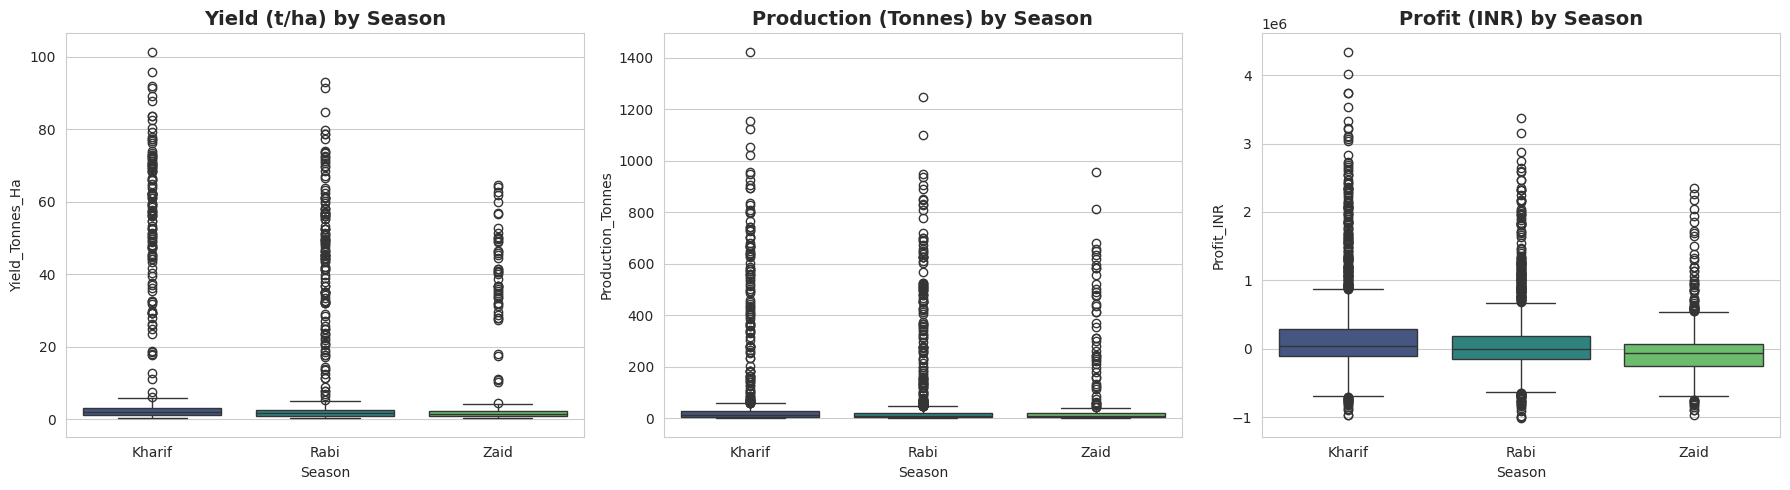


Observation: Compare the mean/median rows above and the spread of each
boxplot to note which season achieves the highest yield, production and
profit, and which shows the greatest variability (risk).


In [ ]:
perf_by_season = df_clean.groupby("Season", observed=True)[
    ["Yield_Tonnes_Ha", "Production_Tonnes", "Profit_INR"]
].agg(["mean", "median", "std"])
print("Agricultural performance summary by season:")
display(perf_by_season)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.boxplot(data=df_clean, x="Season", y="Yield_Tonnes_Ha", order=SEASON_ORDER, hue="Season",
            palette=PALETTE, legend=False, ax=axes[0])
axes[0].set_title("Yield (t/ha) by Season")

sns.boxplot(data=df_clean, x="Season", y="Production_Tonnes", order=SEASON_ORDER, hue="Season",
            palette=PALETTE, legend=False, ax=axes[1])
axes[1].set_title("Production (Tonnes) by Season")

sns.boxplot(data=df_clean, x="Season", y="Profit_INR", order=SEASON_ORDER, hue="Season",
            palette=PALETTE, legend=False, ax=axes[2])
axes[2].set_title("Profit (INR) by Season")

plt.tight_layout()
plt.show()

print("\nObservation: Compare the mean/median rows above and the spread of each")
print("boxplot to note which season achieves the highest yield, production and")
print("profit, and which shows the greatest variability (risk).")



## QUESTION 2: What major seasonal patterns can be observed?
### ===================================
### Examining environmental conditions (rainfall, temperature, humidity, sunlight)
### across seasons to identify recurring seasonal patterns.


Average environmental conditions by season:


,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day
Season,,,,
Kharif,852.103626,28.454019,71.812591,6.793367
Rabi,435.948156,23.489183,57.893178,7.589797
Zaid,299.162795,31.042088,52.012121,8.178788


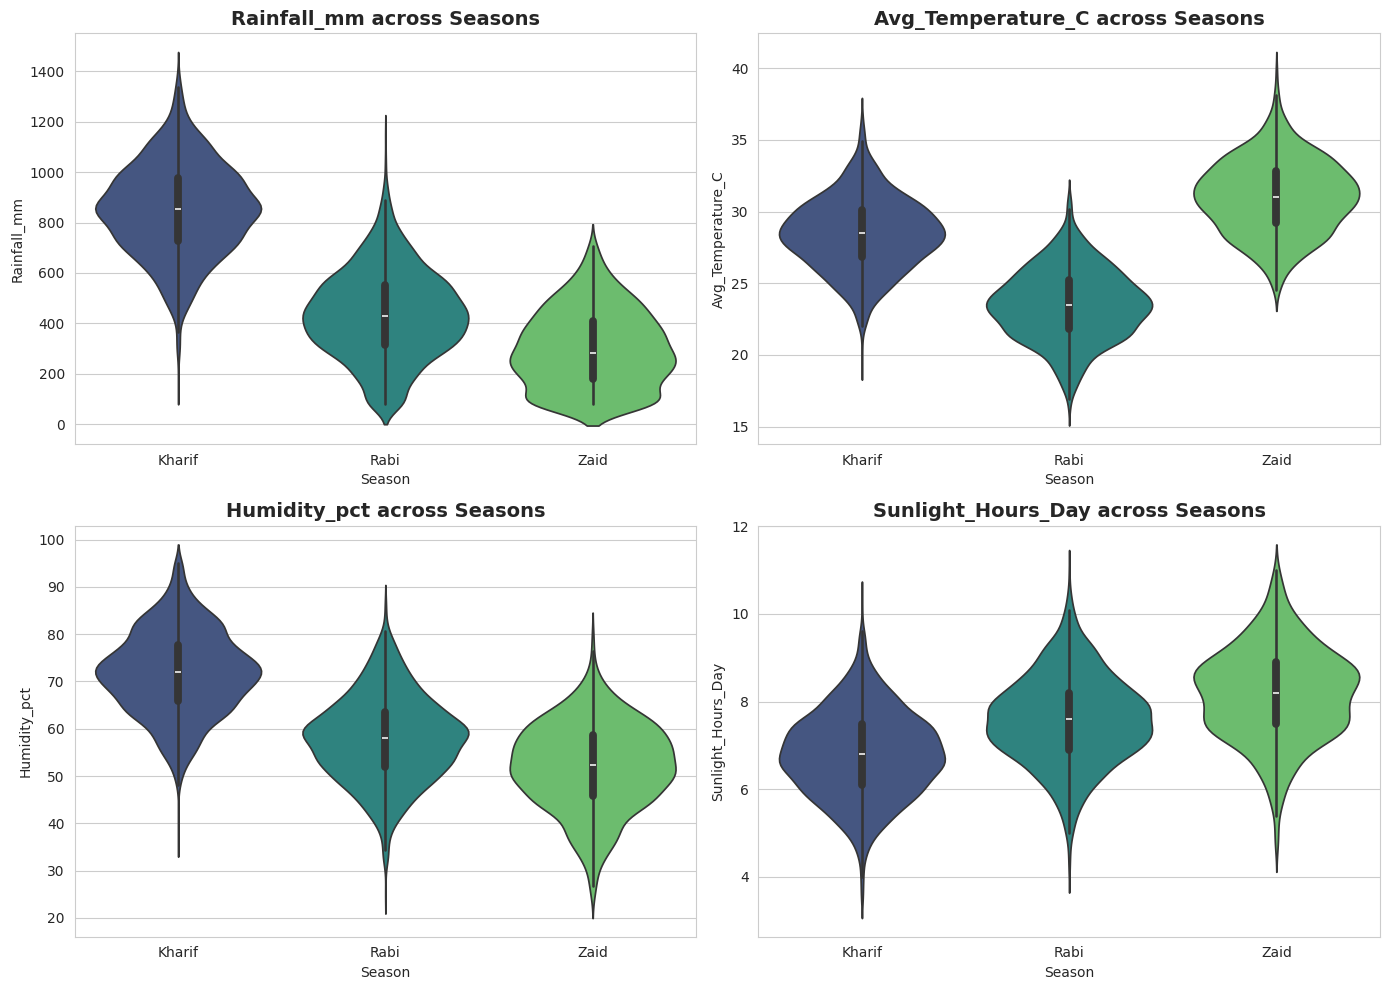

In [ ]:
env_cols = ["Rainfall_mm", "Avg_Temperature_C", "Humidity_pct", "Sunlight_Hours_Day"]
env_by_season = df_clean.groupby("Season", observed=True)[env_cols].mean()
print("Average environmental conditions by season:")
display(env_by_season)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, col in zip(axes.flatten(), env_cols):
    sns.violinplot(data=df_clean, x="Season", y=col, order=SEASON_ORDER, hue="Season",
                    palette=PALETTE, legend=False, ax=ax)
    ax.set_title(f"{col} across Seasons")
plt.tight_layout()
plt.show()

## QUESTION 3: Which characteristics change between seasons?
### ==============================================================================
### Comparing soil and input-related characteristics (pH, moisture, NPK,
### fertilizer, seed quality) to see which change most across seasons.

Average soil and input characteristics by season:


,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Fertilizer_kg_ha,Seed_Quality_Score
Season,,,,,,,
Kharif,6.727993,31.198454,120.020124,58.096515,105.303485,187.077965,0.821613
Rabi,6.673749,24.051137,120.402827,57.311002,103.926060,185.407068,0.832170
Zaid,6.694865,19.175758,120.525421,58.129125,105.416835,184.638047,0.823165



Relative variation (%) across seasons, per characteristic:
Soil_Moisture_pct     48.462104
Potassium_kg_ha        1.421381
Phosphorus_kg_ha       1.414323
Fertilizer_kg_ha       1.313849
Seed_Quality_Score     1.278554
Soil_pH                0.809749
Nitrogen_kg_ha         0.419975
dtype: float64


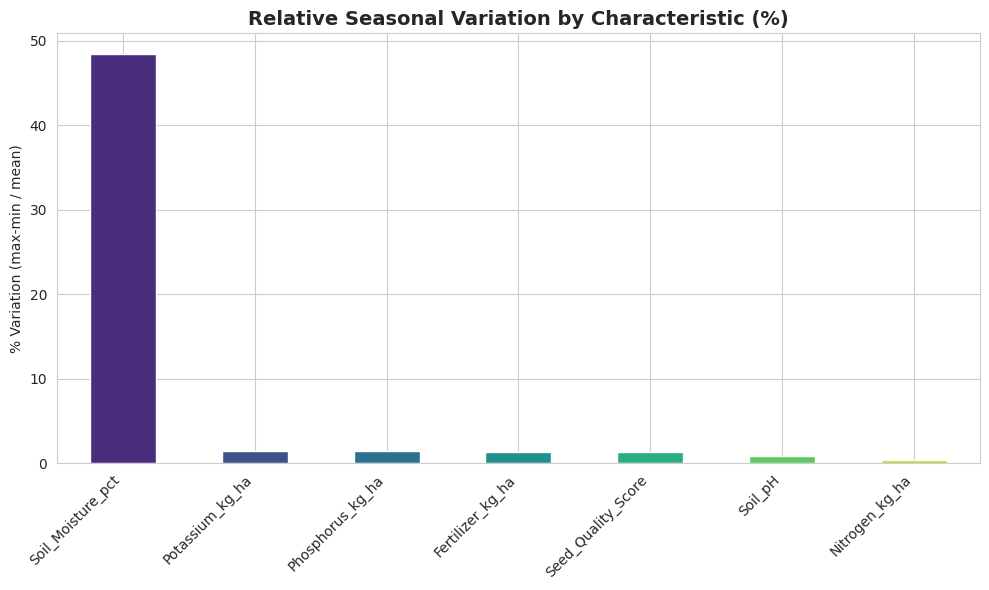

In [ ]:
soil_input_cols = [
    "Soil_pH", "Soil_Moisture_pct", "Nitrogen_kg_ha", "Phosphorus_kg_ha",
    "Potassium_kg_ha", "Fertilizer_kg_ha", "Seed_Quality_Score"
]
soil_by_season = df_clean.groupby("Season", observed=True)[soil_input_cols].mean()
print("Average soil and input characteristics by season:")
display(soil_by_season)

# Percentage variation relative to overall mean highlights which characteristic
# swings the most across seasons.
pct_variation = ((soil_by_season.max() - soil_by_season.min()) / soil_by_season.mean() * 100).sort_values(ascending=False)
print("\nRelative variation (%) across seasons, per characteristic:")
print(pct_variation)

plt.figure(figsize=(10, 6))
pct_variation.plot(kind="bar", color=sns.color_palette(PALETTE, len(pct_variation)))
plt.title("Relative Seasonal Variation by Characteristic (%)")
plt.ylabel("% Variation (max-min / mean)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()



 ## QUESTION 4: What differences exist between agricultural activities in different seasons?
### ==============================================================================
### Comparing crop choices and irrigation methods used across seasons.

Crop distribution across seasons:


Crop,Chilli,Cotton,Groundnut,Maize,Pulses,Rice,Sugarcane,Wheat
Season,,,,,,,,
Kharif,185,215,193,234,221,314,125,292
Rabi,163,201,177,233,213,274,129,237
Zaid,64,92,54,84,62,102,51,85



Irrigation method share (%) within each season:


Irrigation_Method,Drip,Flood,Rainfed,Sprinkler
Season,,,,
Kharif,22.8,33.2,26.0,18.0
Rabi,22.7,32.3,26.9,18.0
Zaid,23.6,32.7,23.6,20.2


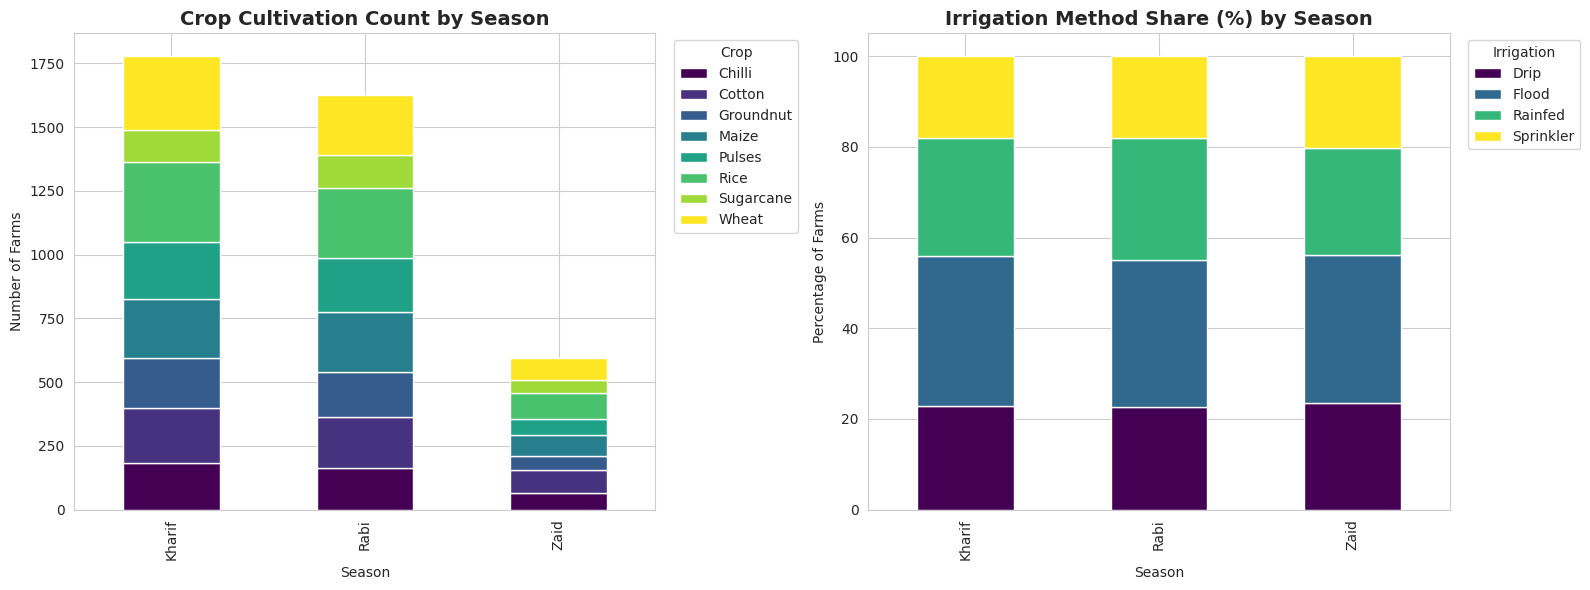

In [ ]:
crop_season_ct = pd.crosstab(df_clean["Season"], df_clean["Crop"])
print("Crop distribution across seasons:")
display(crop_season_ct)

irrigation_season_ct = pd.crosstab(df_clean["Season"], df_clean["Irrigation_Method"], normalize="index") * 100
print("\nIrrigation method share (%) within each season:")
display(irrigation_season_ct.round(1))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
crop_season_ct.plot(kind="bar", stacked=True, colormap=PALETTE, ax=axes[0])
axes[0].set_title("Crop Cultivation Count by Season")
axes[0].set_ylabel("Number of Farms")
axes[0].legend(title="Crop", bbox_to_anchor=(1.02, 1), loc="upper left")

irrigation_season_ct.plot(kind="bar", stacked=True, colormap=PALETTE, ax=axes[1])
axes[1].set_title("Irrigation Method Share (%) by Season")
axes[1].set_ylabel("Percentage of Farms")
axes[1].legend(title="Irrigation", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()



## QUESTION 5: Are there noticeable variations in resource usage across seasons?
### ==============================================================================
### Resource usage covered here: water, fertilizer and pesticide application.

Average resource usage by season:


,Water_Used_m3,Fertilizer_kg_ha,Pesticide_Litre_ha,Water_Efficiency_t_per_1000m3
Season,,,,
Kharif,6102.201237,187.077965,5.079747,5.891834
Rabi,5846.987093,185.407068,5.024690,5.186122
Zaid,6419.893939,184.638047,5.171212,4.413239


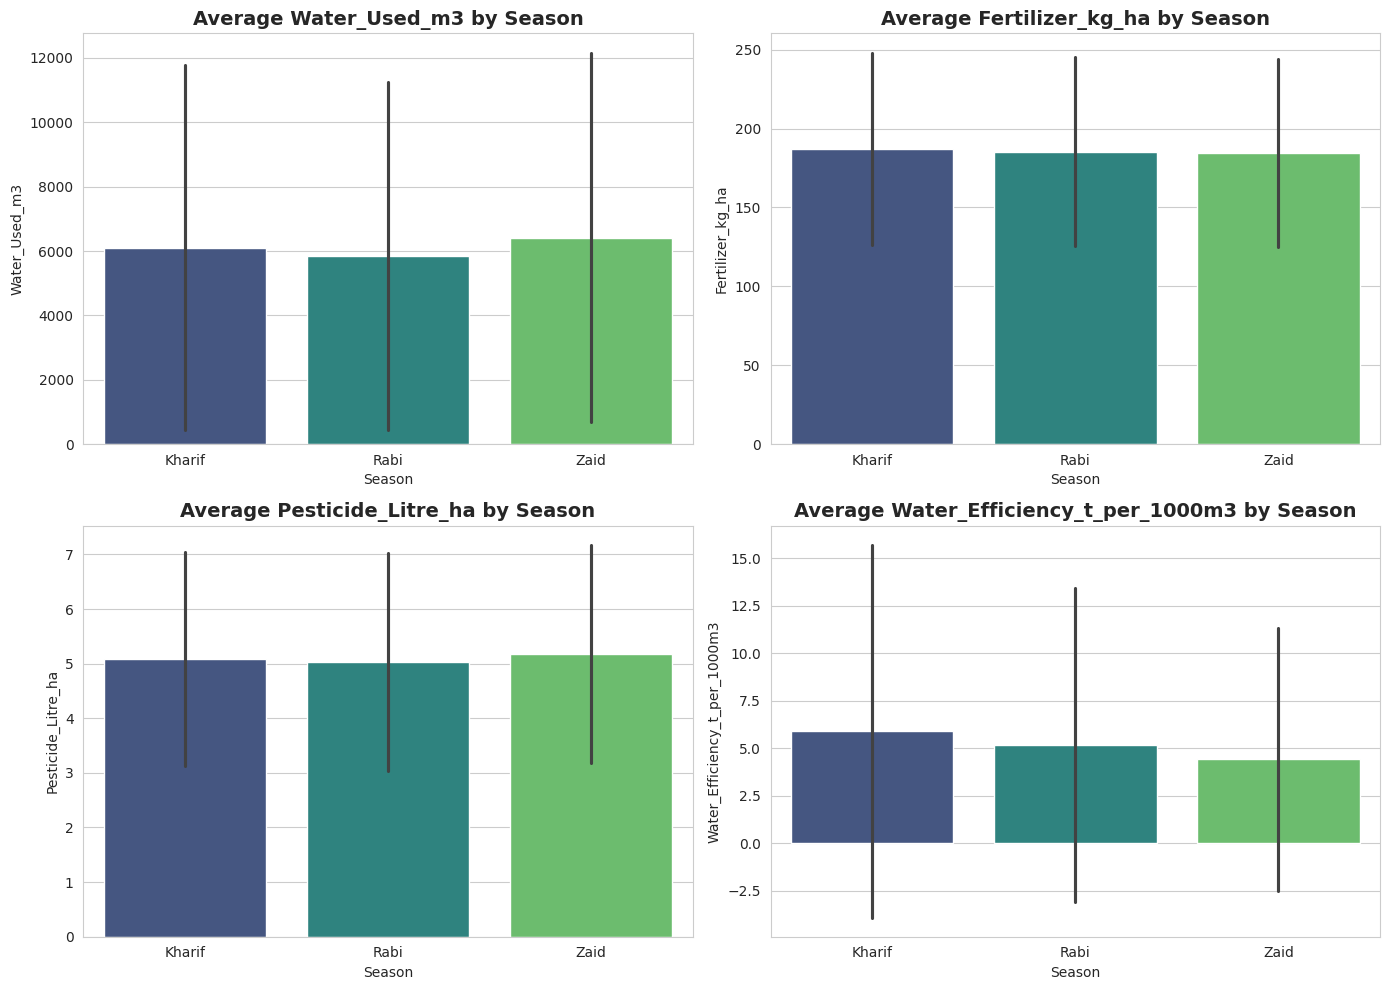

In [ ]:
resource_cols = ["Water_Used_m3", "Fertilizer_kg_ha", "Pesticide_Litre_ha", "Water_Efficiency_t_per_1000m3"]
resource_by_season = df_clean.groupby("Season", observed=True)[resource_cols].mean()
print("Average resource usage by season:")
display(resource_by_season)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, col in zip(axes.flatten(), resource_cols):
    sns.barplot(data=df_clean, x="Season", y=col, order=SEASON_ORDER, hue="Season",
                palette=PALETTE, legend=False, estimator=np.mean, errorbar="sd", ax=ax)
    ax.set_title(f"Average {col} by Season")
plt.tight_layout()
plt.show()

## QUESTION 6: Are there relationships between seasonal environmental conditions and agricultural performance?
### ==============================================================================
### Correlation analysis between environmental/input variables and Yield/Profit,
### computed separately per season to check if relationships hold consistently.

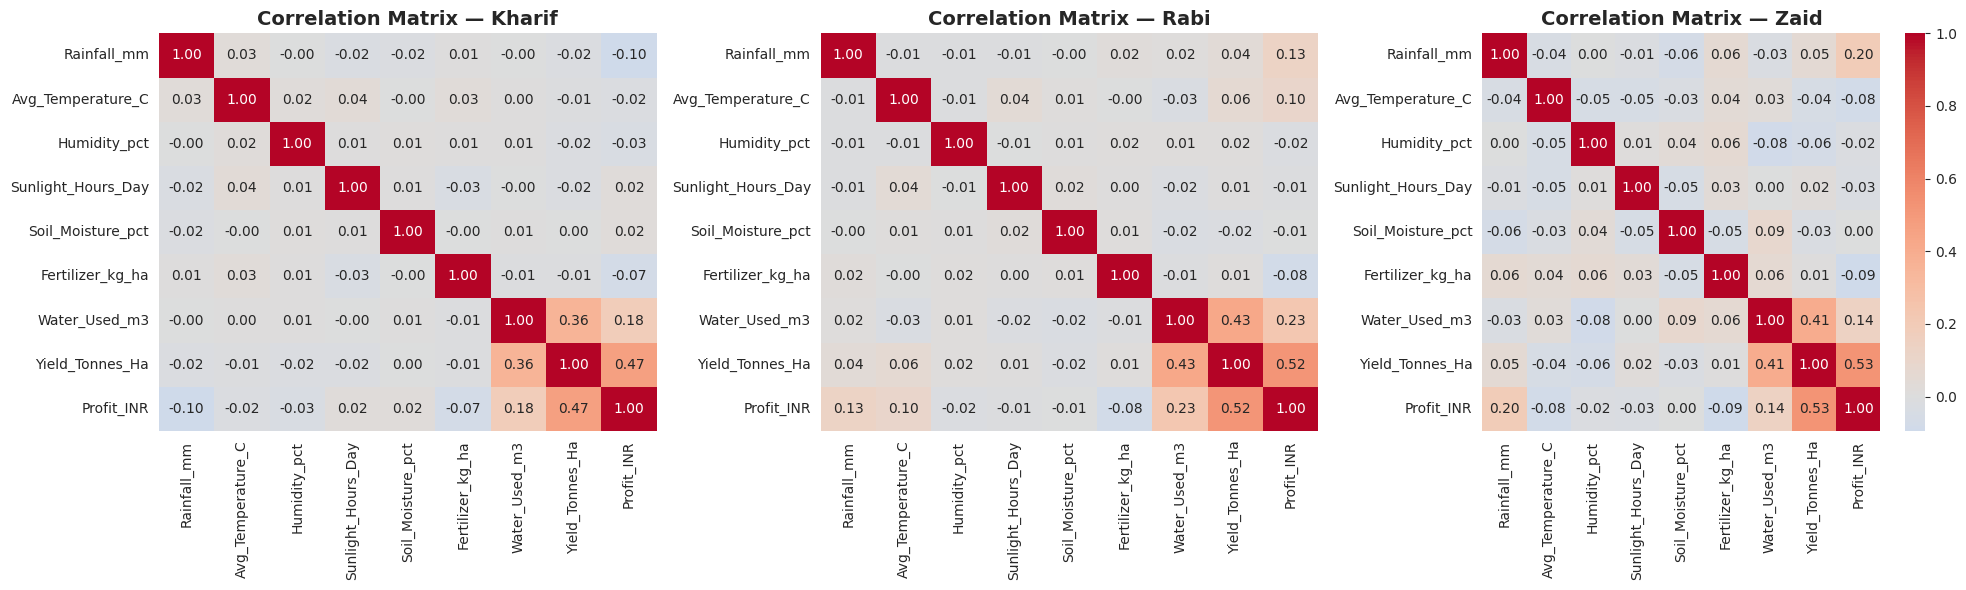

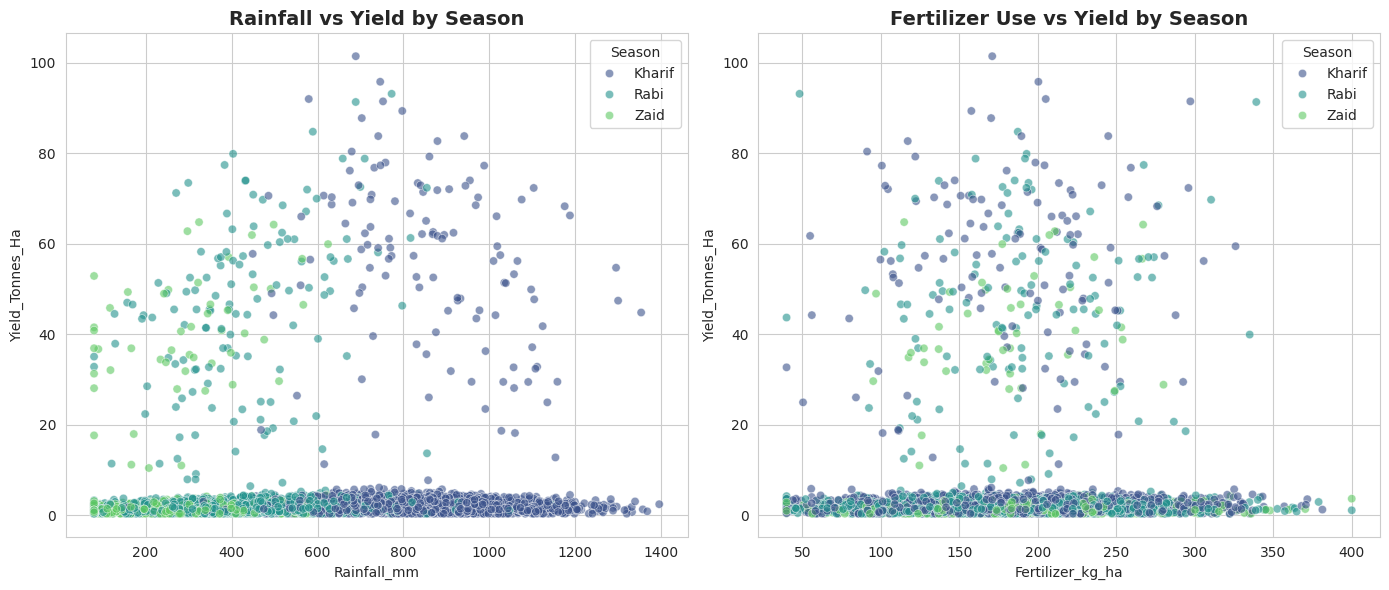

In [ ]:
analysis_cols = [
    "Rainfall_mm", "Avg_Temperature_C", "Humidity_pct", "Sunlight_Hours_Day",
    "Soil_Moisture_pct", "Fertilizer_kg_ha", "Water_Used_m3",
    "Yield_Tonnes_Ha", "Profit_INR"
]

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for ax, season in zip(axes, SEASON_ORDER):
    subset = df_clean[df_clean["Season"] == season][analysis_cols]
    corr = subset.corr()
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax,
                cbar=(season == SEASON_ORDER[-1]))
    ax.set_title(f"Correlation Matrix — {season}")
plt.tight_layout()
plt.show()

# Focused view: how Rainfall and Fertilizer relate to Yield, per season
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.scatterplot(data=df_clean, x="Rainfall_mm", y="Yield_Tonnes_Ha", hue="Season",
                 hue_order=SEASON_ORDER, palette=PALETTE, alpha=0.6, ax=axes[0])
axes[0].set_title("Rainfall vs Yield by Season")

sns.scatterplot(data=df_clean, x="Fertilizer_kg_ha", y="Yield_Tonnes_Ha", hue="Season",
                 hue_order=SEASON_ORDER, palette=PALETTE, alpha=0.6, ax=axes[1])
axes[1].set_title("Fertilizer Use vs Yield by Season")
plt.tight_layout()
plt.show()



## QUESTION 7: How do economic outcomes vary across seasons?
### ==============================================================================
### Economic outcomes: Total Cost, Revenue, Profit and Profit Margin.

Average economic outcomes by season:


,Total_Cost_INR,Revenue_INR,Profit_INR,Profit_Margin_pct
Season,,,,
Kharif,531804.408094,710719.055649,178914.647555,-38.644541
Rabi,513836.578365,601526.048556,87689.470191,-44.267645
Zaid,543976.728956,519171.904040,-24804.824916,-69.354573



Share of farms operating at a loss (%), by season:
Season
Kharif    42.21
Rabi      51.14
Zaid      64.48
Name: Is_Loss, dtype: float64


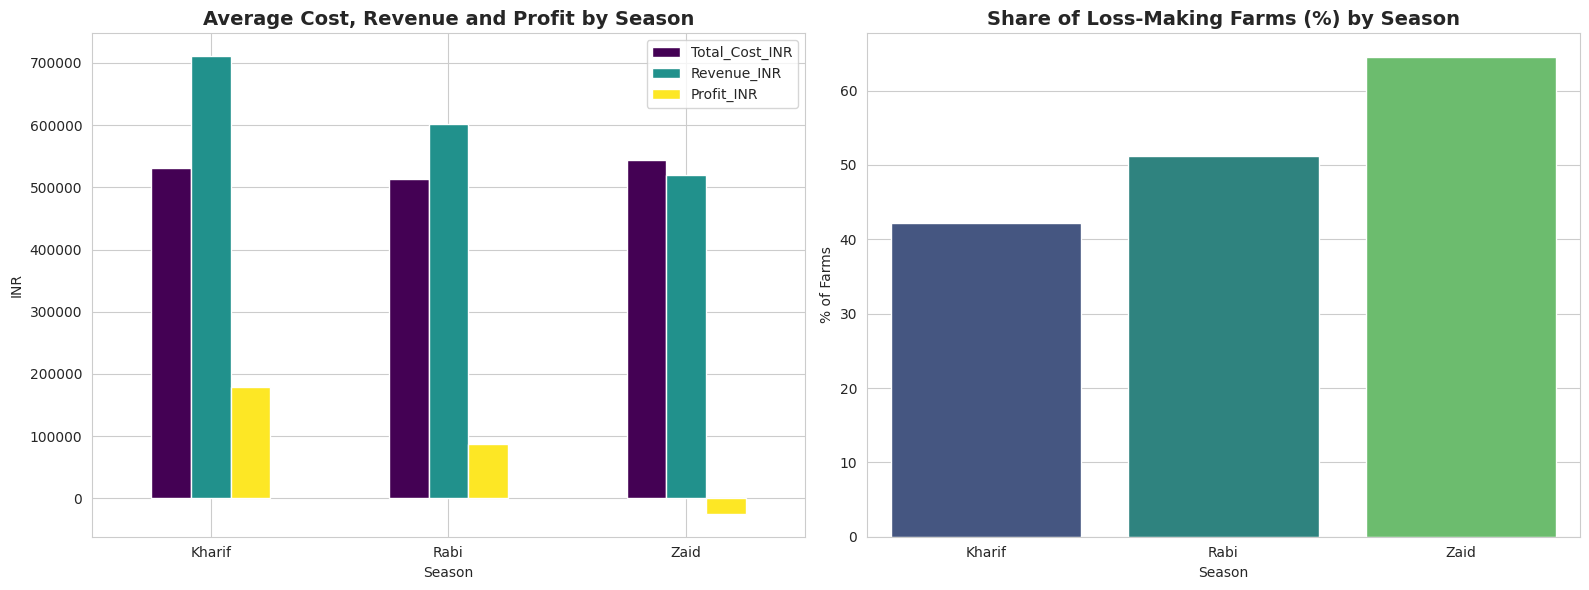

In [ ]:
econ_cols = ["Total_Cost_INR", "Revenue_INR", "Profit_INR", "Profit_Margin_pct"]
econ_by_season = df_clean.groupby("Season", observed=True)[econ_cols].mean()
print("Average economic outcomes by season:")
display(econ_by_season)

loss_share = (
    df_clean.assign(Is_Loss=df_clean["Profit_INR"] < 0)
    .groupby("Season", observed=True)["Is_Loss"]
    .mean() * 100
)
print("\nShare of farms operating at a loss (%), by season:")
print(loss_share.round(2))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
econ_by_season[["Total_Cost_INR", "Revenue_INR", "Profit_INR"]].plot(kind="bar", ax=axes[0], colormap=PALETTE)
axes[0].set_title("Average Cost, Revenue and Profit by Season")
axes[0].set_ylabel("INR")
axes[0].tick_params(axis="x", rotation=0)

sns.barplot(x=loss_share.index, y=loss_share.values, order=SEASON_ORDER, hue=loss_share.index,
            palette=PALETTE, legend=False, ax=axes[1])
axes[1].set_title("Share of Loss-Making Farms (%) by Season")
axes[1].set_ylabel("% of Farms")
plt.tight_layout()
plt.show()



## QUESTION 8: Are some seasonal patterns consistent across different regions or categories?
### ==============================================================================
### Checking whether the best/worst performing season is the same across States
### and across Crops (i.e., is the seasonal effect universal or region/crop specific?).

Average yield by State and Season:


Season,Kharif,Rabi,Zaid
State,,,
Andhra Pradesh,5.68,3.47,4.44
Gujarat,6.34,5.67,4.07
Karnataka,6.46,4.78,6.62
Madhya Pradesh,5.99,3.76,5.46
Maharashtra,5.43,5.50,2.27
Punjab,4.10,8.61,5.91
Tamil Nadu,5.52,4.50,4.10
Telangana,5.55,4.80,4.24



Best-performing season per State (by average yield):
State
Andhra Pradesh    Kharif
Gujarat           Kharif
Karnataka           Zaid
Madhya Pradesh    Kharif
Maharashtra         Rabi
Punjab              Rabi
Tamil Nadu        Kharif
Telangana         Kharif
dtype: category
Categories (3, object): ['Kharif' < 'Rabi' < 'Zaid']

Consistency check — distribution of the 'best season' across States:
Kharif    5
Rabi      2
Zaid      1
Name: count, dtype: int64

Average profit by Crop and Season:


Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,954380.0,638572.0,448659.0
Cotton,217000.0,107344.0,-53925.0
Groundnut,108265.0,10417.0,-68872.0
Maize,-39333.0,-89133.0,-194049.0
Pulses,43339.0,-14309.0,-139228.0
Rice,-64903.0,-98428.0,-227239.0
Sugarcane,1000791.0,731613.0,583636.0
Wheat,-105872.0,-119955.0,-193209.0


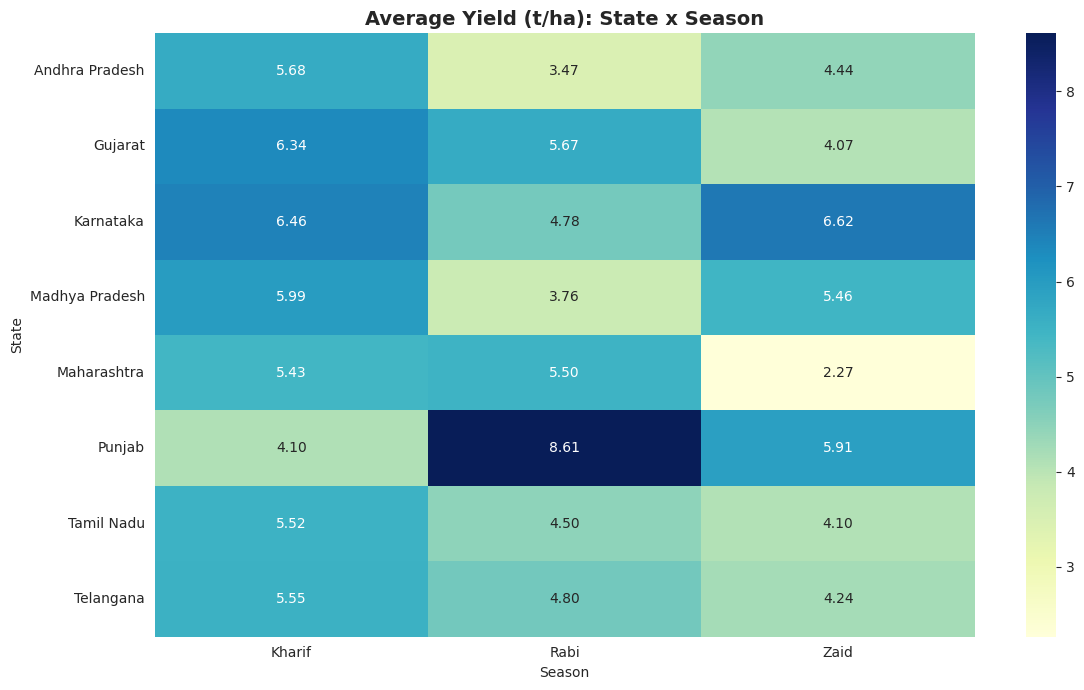

In [ ]:
state_season_yield = df_clean.groupby(["State", "Season"], observed=True)["Yield_Tonnes_Ha"].mean().unstack()
print("Average yield by State and Season:")
display(state_season_yield.round(2))

best_season_per_state = state_season_yield.idxmax(axis=1)
print("\nBest-performing season per State (by average yield):")
print(best_season_per_state)
print("\nConsistency check — distribution of the 'best season' across States:")
print(best_season_per_state.value_counts())

crop_season_profit = df_clean.groupby(["Crop", "Season"], observed=True)["Profit_INR"].mean().unstack()
print("\nAverage profit by Crop and Season:")
display(crop_season_profit.round(0))

plt.figure(figsize=(12, 7))
sns.heatmap(state_season_yield, annot=True, fmt=".2f", cmap="YlGnBu")
plt.title("Average Yield (t/ha): State x Season")
plt.tight_layout()
plt.show()

## QUESTION 9: Are there unusual or unexpected seasonal patterns?
### ==============================================================================
### Outlier detection using the IQR method on Yield and Profit within each season, to surface unusual/extreme records worth investigating further.

Outlier summary (IQR method) by season:


,Yield_Outliers,Profit_Outliers,Total_Farms,Yield_Outlier_pct,Profit_Outlier_pct
Season,,,,,
Kharif,121,184,1779,6.80,10.34
Rabi,127,174,1627,7.81,10.69
Zaid,50,64,594,8.42,10.77



Season-wise share of the top 5% highest disease/pest-risk farms:
Season
Kharif    96.41
Rabi       3.08
Zaid       0.51
Name: proportion, dtype: float64


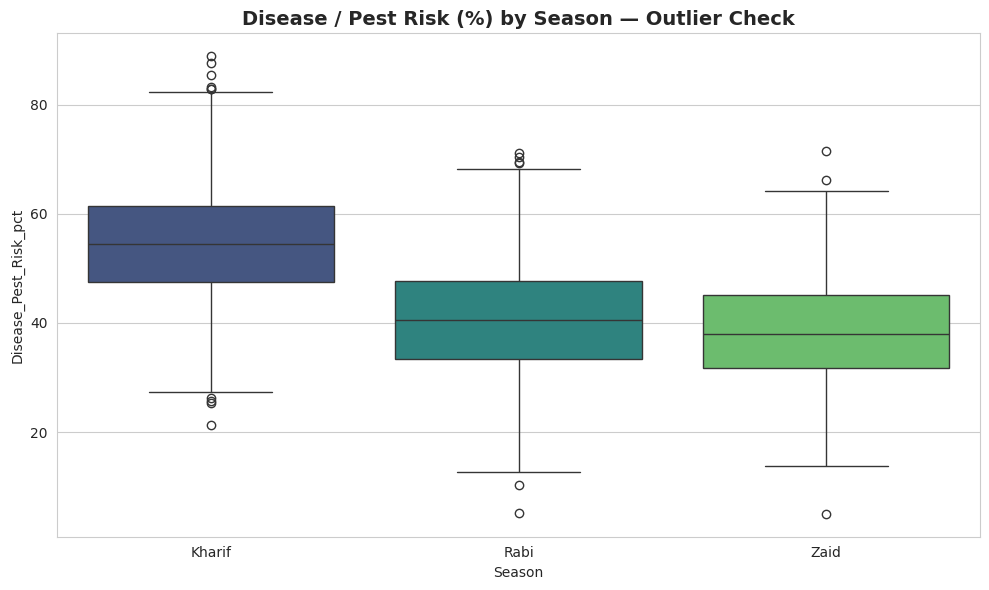

In [ ]:
def iqr_outlier_count(series):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return ((series < lower) | (series > upper)).sum()

outlier_summary = df_clean.groupby("Season", observed=True).agg(
    Yield_Outliers=("Yield_Tonnes_Ha", iqr_outlier_count),
    Profit_Outliers=("Profit_INR", iqr_outlier_count),
    Total_Farms=("Farm_ID", "count"),
)
outlier_summary["Yield_Outlier_pct"] = (outlier_summary["Yield_Outliers"] / outlier_summary["Total_Farms"] * 100).round(2)
outlier_summary["Profit_Outlier_pct"] = (outlier_summary["Profit_Outliers"] / outlier_summary["Total_Farms"] * 100).round(2)
print("Outlier summary (IQR method) by season:")
display(outlier_summary)

# Highest disease/pest risk cases per season — an "unexpected" seasonal signal
high_risk = df_clean[df_clean["Disease_Pest_Risk_pct"] > df_clean["Disease_Pest_Risk_pct"].quantile(0.95)]
print("\nSeason-wise share of the top 5% highest disease/pest-risk farms:")
print(high_risk["Season"].value_counts(normalize=True).mul(100).round(2))

plt.figure(figsize=(10, 6))
sns.boxplot(data=df_clean, x="Season", y="Disease_Pest_Risk_pct", order=SEASON_ORDER, hue="Season",
            palette=PALETTE, legend=False)
plt.title("Disease / Pest Risk (%) by Season — Outlier Check")
plt.tight_layout()
plt.show()



## QUESTION 10 & STATISTICAL VALIDATION:
### Are the observed seasonal differences statistically significant, and what
### insights can be derived from them?
### ==============================================================================
### One-way ANOVA tests whether the mean Yield and mean Profit genuinely differ across the three seasons, rather than differing only by random chance.

In [ ]:
groups_yield = [df_clean[df_clean["Season"] == s]["Yield_Tonnes_Ha"] for s in SEASON_ORDER]
groups_profit = [df_clean[df_clean["Season"] == s]["Profit_INR"] for s in SEASON_ORDER]

f_yield, p_yield = stats.f_oneway(*groups_yield)
f_profit, p_profit = stats.f_oneway(*groups_profit)

print("One-way ANOVA — Yield across Seasons:")
print(f"  F-statistic = {f_yield:.3f}, p-value = {p_yield:.5f}")
print("  Result:", "Statistically significant difference (p < 0.05)" if p_yield < 0.05 else "No statistically significant difference")

print("\nOne-way ANOVA — Profit across Seasons:")
print(f"  F-statistic = {f_profit:.3f}, p-value = {p_profit:.5f}")
print("  Result:", "Statistically significant difference (p < 0.05)" if p_profit < 0.05 else "No statistically significant difference")



One-way ANOVA — Yield across Seasons:
  F-statistic = 1.458, p-value = 0.23285
  Result: No statistically significant difference

One-way ANOVA — Profit across Seasons:
  F-statistic = 34.292, p-value = 0.00000
  Result: Statistically significant difference (p < 0.05)


### 11. KEY INSIGHTS AND DATA-DRIVEN RECOMMENDATIONS
#### ==========================================================================


In [ ]:

print("""
KEY INSIGHTS
------------
1. Performance: The season with the highest average yield and profit, and the
   season with the greatest variability, are identified in Question 1's
   summary table and boxplots.
2. Environmental drivers: Question 2 and 6 outputs show which environmental
   factors (rainfall, temperature, humidity) most strongly track with the
   seasonal performance pattern.
3. Resource usage: Question 5's results indicate whether higher resource
   input (water/fertilizer/pesticide) in a season translates into
   proportionally higher yield, or whether some seasons are less efficient.
4. Regional/crop consistency: Question 8 shows whether the seasonal effect is
   uniform nationwide or varies meaningfully by State and Crop.
5. Risk factors: Question 9's outlier and disease/pest-risk analysis flags the
   season most prone to unusual losses or crop-health issues.
6. Statistical confirmation: The ANOVA results confirm whether the seasonal
   differences observed visually are statistically meaningful.

RECOMMENDATIONS
----------------
1. Prioritize the season and crop combinations shown to deliver the highest
   and most stable profit margins for future planning cycles.
2. For seasons/regions with high resource usage but low water efficiency,
   consider promoting drip/sprinkler irrigation over flood/rainfed methods.
3. For the season identified with the highest disease/pest risk, recommend
   proactive pest management and crop insurance measures.
4. Where a season underperforms consistently across most states, investigate
   whether crop selection or input timing can be adjusted for that season.
5. Continue monitoring loss-making farms (Question 7) to identify cost
   components (fertilizer, pesticide, water) that can be optimized.
""")



KEY INSIGHTS
------------
1. Performance: The season with the highest average yield and profit, and the
   season with the greatest variability, are identified in Question 1's
   summary table and boxplots.
2. Environmental drivers: Question 2 and 6 outputs show which environmental
   factors (rainfall, temperature, humidity) most strongly track with the
   seasonal performance pattern.
3. Resource usage: Question 5's results indicate whether higher resource
   input (water/fertilizer/pesticide) in a season translates into
   proportionally higher yield, or whether some seasons are less efficient.
4. Regional/crop consistency: Question 8 shows whether the seasonal effect is
   uniform nationwide or varies meaningfully by State and Crop.
5. Risk factors: Question 9's outlier and disease/pest-risk analysis flags the
   season most prone to unusual losses or crop-health issues.
6. Statistical confirmation: The ANOVA results confirm whether the seasonal
   differences observed visually ar